In [4]:
import numpy as np
import matplotlib.pyplot as plt


from easydynamics.sample import BrownianTranslationalDiffusion

from easydynamics.sample import SampleModel
from easydynamics.sample import LorentzianComponent
from easydynamics.sample import DeltaFunctionComponent

from easydynamics.sample import GaussianComponent

from easydynamics.resolution import ResolutionHandler

%matplotlib widget

Text(0, 0.5, 'HWHM (meV)')

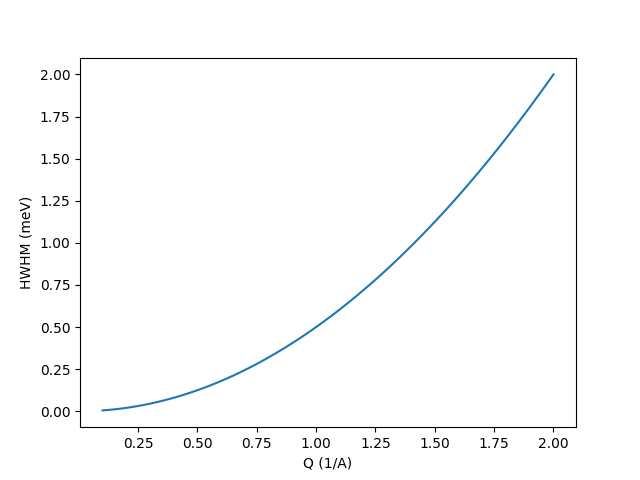

In [5]:


model=BrownianTranslationalDiffusion(name="DiffusionModel", diffusion_coefficient=0.5)
Q=np.linspace(0.1,2,100)
HWHM=model.calculate_width(Q)


plt.figure()
plt.plot(Q,HWHM)
plt.xlabel('Q (1/A)')
plt.ylabel('HWHM (meV)')

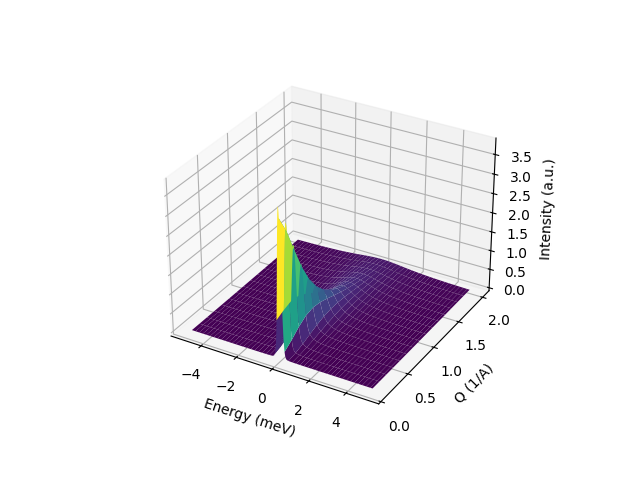

In [6]:
Q=np.linspace(0.1,2,16)
E=np.linspace(-5,5,1001)
HWHM=model.calculate_width(Q)

QQISF=model.calculate_QISF(Q)
EISF=model.calculate_EISF(Q)

resolution=GaussianComponent(name="Resolution", area=1,width=0.1)

resolution_handler=ResolutionHandler()

sample_model=[]
convoluted_signal=np.zeros((len(Q),len(E)))
for i in range(len(Q)):
    sample_model.append(SampleModel(name=f"SampleModel_{i}"))

    sample_model[i].add_component(DeltaFunctionComponent(area=EISF[i], name="Elastic"))
    sample_model[i].add_component(LorentzianComponent(area=QQISF[i], name="QuasiElastic", width=HWHM[i]) )

    convoluted_signal[i,:] = resolution_handler.convolve(E,sample_model[i],resolution)

ax = plt.figure().add_subplot(projection='3d')

E_grid, Q_grid = np.meshgrid(E, Q)
ax.plot_surface(E_grid, Q_grid, convoluted_signal, cmap='viridis')
ax.set_xlabel('Energy (meV)')
ax.set_ylabel('Q (1/A)')
ax.set_zlabel('Intensity (a.u.)')
plt.show()